<a href="https://colab.research.google.com/github/Kaderbalde/Projet_Outils_Versioning/blob/test/ml_webapp_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Projet ML WebApp - Version Google Colab
Ce notebook permet de simuler l'entraînement de modèles de machine learning comme dans ton application Django.

In [1]:
# 📦 Installation des dépendances
!pip install pandas scikit-learn matplotlib


In [2]:
# 📂 Importations
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import files


In [3]:
# 📁 Téléversement du fichier CSV
print("Veuillez téléverser un fichier CSV avec des colonnes numériques uniquement :")
uploaded = files.upload()


Veuillez téléverser un fichier CSV avec des colonnes numériques uniquement :


Saving exemple_donnees_ml.csv to exemple_donnees_ml.csv


In [4]:
# 🧼 Lecture et validation des données
for filename in uploaded:
    df = pd.read_csv(filename)

print("✅ Aperçu des données :")
display(df.head())

if df.empty or df.shape[1] < 2:
    raise ValueError("Le fichier doit contenir au moins deux colonnes.")

if not all(pd.api.types.is_numeric_dtype(df[col]) for col in df.columns):
    raise ValueError("Toutes les colonnes doivent être numériques.")


✅ Aperçu des données :


,age,salaire,note
0,25,25000,3.2
1,32,32000,4.1
2,47,47000,5.0
3,51,51000,4.7
4,62,62000,4.9


from matplotlib import pyplot as plt
_df_0['age'].plot(kind='hist', bins=20, title='age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['salaire'].plot(kind='hist', bins=20, title='salaire')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['note'].plot(kind='hist', bins=20, title='note')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['salaire']
  ys = series['note']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_7.sort_values('salaire', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('salaire')
_ = plt.ylabel('note')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['salaire']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'salaire'}, axis=1)
              .sort_values('salaire', ascending=True))
  xs = counted['salaire']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_8.sort_values('salaire', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('salaire')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_9['age'].plot(kind='line', figsize=(8, 4), title='age')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['salaire'].plot(kind='line', figsize=(8, 4), title='salaire')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_11['note'].plot(kind='line', figsize=(8, 4), title='note')
plt.gca().spines[['top', 'right']].set_visible(False)

In [5]:
# 🎛️ Sélection du modèle
modele = 'rf'  # Options : 'lr', 'svm', 'rf'

if modele == 'svm':
    model = SVR()
elif modele == 'rf':
    model = RandomForestRegressor()
else:
    model = LinearRegression()


In [6]:
# 📈 Entraînement du modèle
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Modèle : {model.__class__.__name__}")
print(f"MSE : {mse:.4f}")
print(f"Score R² : {r2:.4f}")


Modèle : RandomForestRegressor
MSE : 0.3978
Score R² : -2.2473


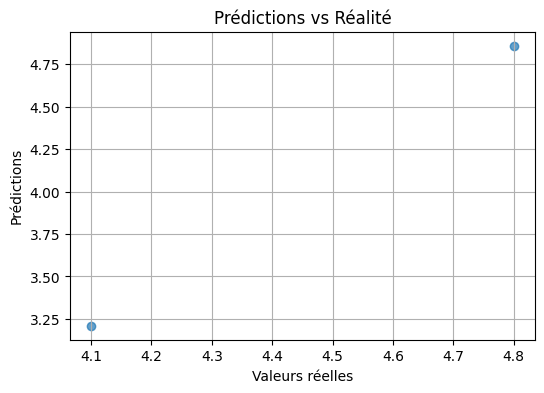

In [7]:
# 📊 Visualisation des résultats
plt.figure(figsize=(6, 4))
plt.scatter(y_test, predictions, alpha=0.7)
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Prédictions vs Réalité")
plt.grid(True)
plt.show()
